In [22]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import warnings
warnings.filterwarnings('ignore')

file_path = "ReviewsAmazon.csv"
df = pd.read_csv(file_path)

In [4]:
print("Dataset shape:", df.shape)
print("\nFirst 3 rows:")
print(df.head(3))

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (568454, 10)

First 3 rows:
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bought several of the Vitality canned d...  
1      Not as Advertised  Product arrived labeled as Jumbo Salted Peanut...  
2  "Delight" says it all  This is a confection that has been around a fe...  

Column names:
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',

In [6]:
# Create sentiment labels from Score
# Positive: Score 4-5, Negative: Score 1-2, Neutral: Score 3
def create_sentiment_label(score):
    if score >= 4:
        return 'positive'
    elif score == 3:
        return 'neutral'
    else:
        return 'negative'

df['sentiment'] = df['Score'].apply(create_sentiment_label)



Sentiment distribution:
sentiment
positive    443777
negative     82037
neutral      42640
Name: count, dtype: int64
sentiment
positive    0.780674
negative    0.144316
neutral     0.075010
Name: proportion, dtype: float64


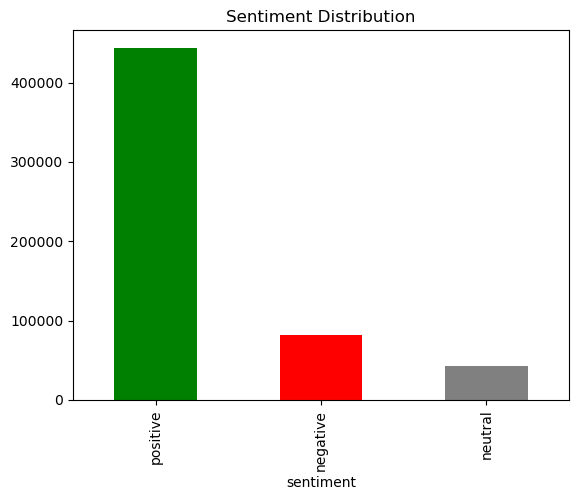

In [10]:
# Check class distribution
print("\nSentiment distribution:")
print(df['sentiment'].value_counts())
print(df['sentiment'].value_counts(normalize=True))

# Visualize
df['sentiment'].value_counts().plot(kind='bar', color=['green', 'red', 'gray'])
plt.title('Sentiment Distribution')
plt.show()

In [13]:
# Combine Summary and Text for better context
df['combined_text'] = df['Summary'].fillna('') + ' ' + df['Text'].fillna('')

# Initialize Lemmatizer
lemmatizer = WordNetLemmatizer()

# Preprocessing function
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize, remove stopwords, lemmatize
    stop_words = set(stopwords.words('english'))
    
    words = text.split()
    negation_words = {'no', 'not', 'nor', 'neither', 'never', 'none'}
    stop_words = stop_words - negation_words
    
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return ' '.join(words)

# Apply to smaller sample first
df_sample = df.sample(n=10000, random_state=42)
df_sample['processed_text'] = df_sample['combined_text'].apply(preprocess_text)

In [15]:
# For binary classification (remove neutral)
df_binary = df_sample[df_sample['sentiment'] != 'neutral']

# For multi-class (keep all three)
df_multiclass = df_sample

# Prepare features and labels
X_binary = df_binary['processed_text']
y_binary = df_binary['sentiment']

X_multiclass = df_multiclass['processed_text']
y_multiclass = df_multiclass['sentiment']

# Split into train and test (80-20 split)
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binary, y_binary, test_size=0.2, random_state=42
)

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multiclass, y_multiclass, test_size=0.2, random_state=42
)

print(f"Binary train size: {len(X_train_bin)}, test size: {len(X_test_bin)}")
print(f"Multi-class train size: {len(X_train_multi)}, test size: {len(X_test_multi)}")

Binary train size: 7400, test size: 1850
Multi-class train size: 8000, test size: 2000


In [16]:
# Create Bag of Words features
vectorizer = CountVectorizer(max_features=5000)

# For binary classification
X_train_bin_bow = vectorizer.fit_transform(X_train_bin)
X_test_bin_bow = vectorizer.transform(X_test_bin)

# For multi-class
X_train_multi_bow = vectorizer.fit_transform(X_train_multi)
X_test_multi_bow = vectorizer.transform(X_test_multi)

print(f"Feature matrix shape: {X_train_bin_bow.shape}")
print(f"Number of features: {len(vectorizer.get_feature_names_out())}")

Feature matrix shape: (7400, 5000)
Number of features: 5000


In [17]:
# Initialize models
nb_model = MultinomialNB()
svm_model = SVC(kernel='linear', random_state=42)

# Train Naive Bayes on binary
print("Training Naive Bayes...")
nb_model.fit(X_train_bin_bow, y_train_bin)
y_pred_nb = nb_model.predict(X_test_bin_bow)

# Evaluate
print(f"Naive Bayes Accuracy: {accuracy_score(y_test_bin, y_pred_nb):.4f}")
print(classification_report(y_test_bin, y_pred_nb))

# Train SVM on binary
print("\nTraining SVM...")
svm_model.fit(X_train_bin_bow, y_train_bin)
y_pred_svm = svm_model.predict(X_test_bin_bow)

# Evaluate
print(f"SVM Accuracy: {accuracy_score(y_test_bin, y_pred_svm):.4f}")
print(classification_report(y_test_bin, y_pred_svm))

Training Naive Bayes...
Naive Bayes Accuracy: 0.9086
              precision    recall  f1-score   support

    negative       0.69      0.66      0.67       265
    positive       0.94      0.95      0.95      1585

    accuracy                           0.91      1850
   macro avg       0.82      0.81      0.81      1850
weighted avg       0.91      0.91      0.91      1850


Training SVM...
SVM Accuracy: 0.8946
              precision    recall  f1-score   support

    negative       0.62      0.67      0.65       265
    positive       0.94      0.93      0.94      1585

    accuracy                           0.89      1850
   macro avg       0.78      0.80      0.79      1850
weighted avg       0.90      0.89      0.90      1850



In [18]:
# Function to get TextBlob sentiment
def get_textblob_sentiment(text):
    blob = TextBlob(str(text))
    polarity = blob.sentiment.polarity
    if polarity > 0:
        return 'positive'
    elif polarity < 0:
        return 'negative'
    else:
        return 'neutral'

# Apply to test set
y_pred_tb = X_test_bin.apply(get_textblob_sentiment)

# Evaluate
print(f"TextBlob Accuracy: {accuracy_score(y_test_bin, y_pred_tb):.4f}")
print(classification_report(y_test_bin, y_pred_tb))

TextBlob Accuracy: 0.8849
              precision    recall  f1-score   support

    negative       0.66      0.44      0.53       265
     neutral       0.00      0.00      0.00         0
    positive       0.92      0.96      0.94      1585

    accuracy                           0.88      1850
   macro avg       0.53      0.47      0.49      1850
weighted avg       0.88      0.88      0.88      1850



In [19]:
# Initialize VADER
analyzer = SentimentIntensityAnalyzer()

# Function to get VADER sentiment
def get_vader_sentiment(text):
    scores = analyzer.polarity_scores(str(text))
    compound = scores['compound']
    if compound >= 0.05:
        return 'positive'
    elif compound <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# Apply to test set
y_pred_vader = X_test_bin.apply(get_vader_sentiment)

# Evaluate
print(f"VADER Accuracy: {accuracy_score(y_test_bin, y_pred_vader):.4f}")
print(classification_report(y_test_bin, y_pred_vader))

VADER Accuracy: 0.8865
              precision    recall  f1-score   support

    negative       0.73      0.40      0.52       265
     neutral       0.00      0.00      0.00         0
    positive       0.91      0.97      0.94      1585

    accuracy                           0.89      1850
   macro avg       0.55      0.46      0.49      1850
weighted avg       0.89      0.89      0.88      1850



In [23]:
# Prepare data (using your preprocessed df_sample)
df_binary = df_sample[df_sample['sentiment'] != 'neutral']
X = df_binary['processed_text']
y = df_binary['sentiment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 1. BAG OF WORDS
print("="*50)
print("BAG OF WORDS FEATURES")
print("="*50)

bow = CountVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

print(f"Feature shape: {X_train_bow.shape}")

# Train Naive Bayes
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
y_pred_nb_bow = nb_bow.predict(X_test_bow)
print(f"\nNaive Bayes + BoW Accuracy: {accuracy_score(y_test, y_pred_nb_bow):.4f}")

# Train SVM
svm_bow = SVC(kernel='linear', random_state=42)
svm_bow.fit(X_train_bow, y_train)
y_pred_svm_bow = svm_bow.predict(X_test_bow)
print(f"SVM + BoW Accuracy: {accuracy_score(y_test, y_pred_svm_bow):.4f}")

# 2. TF-IDF
print("\n" + "="*50)
print("TF-IDF FEATURES")
print("="*50)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Feature shape: {X_train_tfidf.shape}")

# Train Naive Bayes
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)
print(f"\nNaive Bayes + TF-IDF Accuracy: {accuracy_score(y_test, y_pred_nb_tfidf):.4f}")

# Train SVM
svm_tfidf = SVC(kernel='linear', random_state=42)
svm_tfidf.fit(X_train_tfidf, y_train)
y_pred_svm_tfidf = svm_tfidf.predict(X_test_tfidf)
print(f"SVM + TF-IDF Accuracy: {accuracy_score(y_test, y_pred_svm_tfidf):.4f}")

# 3. COMPARISON
print("\n" + "="*50)
print("SUMMARY COMPARISON")
print("="*50)

comparison_data = {
    'Model': ['Naive Bayes + BoW', 'SVM + BoW', 'Naive Bayes + TF-IDF', 'SVM + TF-IDF'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_nb_bow),
        accuracy_score(y_test, y_pred_svm_bow),
        accuracy_score(y_test, y_pred_nb_tfidf),
        accuracy_score(y_test, y_pred_svm_tfidf)
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

BAG OF WORDS FEATURES
Feature shape: (7400, 5000)

Naive Bayes + BoW Accuracy: 0.9314
SVM + BoW Accuracy: 0.9086

TF-IDF FEATURES
Feature shape: (7400, 5000)

Naive Bayes + TF-IDF Accuracy: 0.8708
SVM + TF-IDF Accuracy: 0.9351

SUMMARY COMPARISON
               Model  Accuracy
   Naive Bayes + BoW  0.931351
           SVM + BoW  0.908649
Naive Bayes + TF-IDF  0.870811
        SVM + TF-IDF  0.935135


Discussion

- SVM with TF-IDF has the best overall performance with an accuracy of 93.51.
- SVM is very robust to overfitting due to maximization of the best fitting line.
- SVM performance dropped when using BoW instead of TF-IDF.

- Naive Bayes performs the best by using BoW features with an accuracy of 93.14%, but performance drop when using TF-IDF.
- Naive Bayes is very good at handling class imbalance.
- It assumes feature independence which is not realistic for texts.

- TextBlob doesnt require any training, and can work immediately on texts.
- Has a high acuracy despite no training, which is 88.49%.
- Failed to detect neutral sentiment.

- VADER is only a bit better compared to TextBlob with an accuracy of 88.65%.
- Still fail to detect neutral sentiment.

SVM with TF-IDF achieves the highest accuracy (93.51%) for sentiment classification 
on this dataset, followed closely by Naive Bayes with BoW (93.14%). Both 
significantly outperform lexicon-based methods (88-89%). However, all models 
struggle with the minority negative class due to severe class imbalance (78% 
positive). For practical applications, choose SVM+TF-IDF for maximum accuracy 
or Naive Bayes+BoW for speed, and consider addressing class imbalance for 
better minority class performance.

In [27]:
# Save the processed text data with labels
df_sample[['combined_text', 'processed_text', 'sentiment', 'Score']].to_csv('preprocessed_reviews.csv', index=False)
print("Saved preprocessed_reviews.csv")

# Save Bag of Words features
import pandas as pd
from scipy.sparse import save_npz

# Convert BoW features to DataFrame and save as CSV
bow_df = pd.DataFrame(
    X_train_bin_bow.toarray(), 
    columns=bow.get_feature_names_out()
)
bow_df['sentiment'] = y_train_bin.values
bow_df.to_csv('bow_features_train.csv', index=False)
print("Saved bow_features_train.csv")

# Save TF-IDF features
tfidf_df = pd.DataFrame(
    X_train_tfidf.toarray(),
    columns=tfidf.get_feature_names_out()
)
tfidf_df['sentiment'] = y_train_bin.values
tfidf_df.to_csv('tfidf_features_train.csv', index=False)
print("Saved tfidf_features_train.csv")

Saved preprocessed_reviews.csv
Saved bow_features_train.csv
Saved tfidf_features_train.csv
